# Phase 3 - Probability & Inferential Statistics

## Objectives

This phase applies probability and inferential statistical concepts to the processed hotel booking dataset.

### Topics Covered

- Probability Distribution
- Conditional Probability
- Sampling Distribution
- Central Limit Theorem (CLT)
- Confidence Interval
- Population vs Sample
- Sampling Techniques
- Point Estimation
- Confidence Level
- Margin of Error

The results from this phase will be used in hypothesis testing and statistical decision-making.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("processed_hotel_bookings.csv")

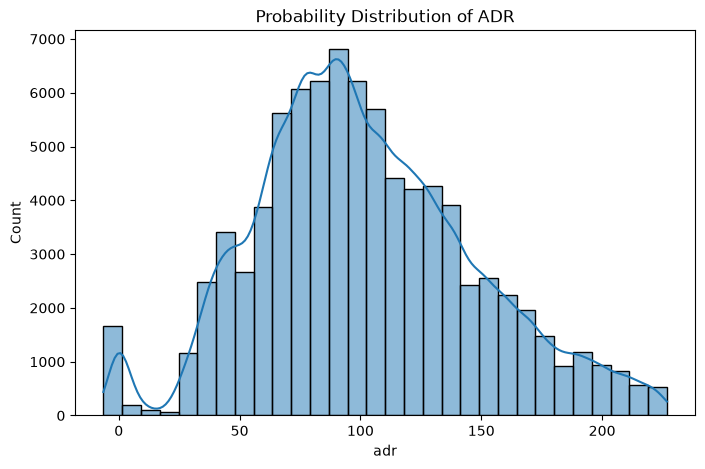

In [2]:
#Probability Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["adr"], bins=30, kde=True)

plt.title("Probability Distribution of ADR")

plt.show()

In [3]:
#Conditional Probability

#Probability of cancellation given Resort Hotel

resort = df[df["hotel"]==0]

conditional_probability = (
    resort["is_canceled"].sum()/len(resort)
)

print("Conditional Probability :",round(conditional_probability,3))

Conditional Probability : 0.3


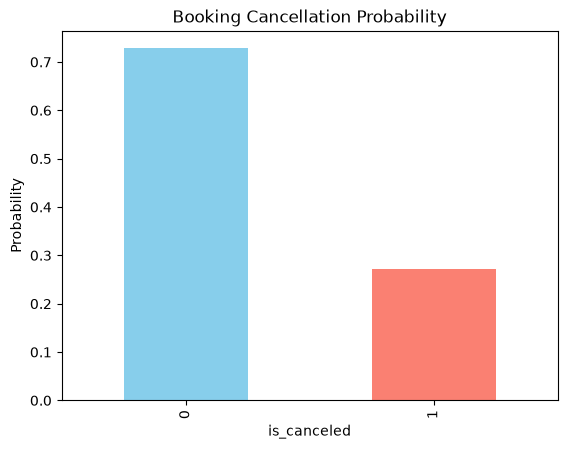

In [4]:
#Probability Chart
prob = df["is_canceled"].value_counts(normalize=True)

prob.plot(kind="bar",color=["skyblue","salmon"])

plt.title("Booking Cancellation Probability")

plt.ylabel("Probability")

plt.show()

In [5]:
#Sampling Distribution

sample = df["adr"].sample(500, random_state=42)

print("Sample Mean :",sample.mean())
print("Population Mean :",df["adr"].mean())

Sample Mean : 104.27945999999999
Population Mean : 101.9307782289478


In [6]:
#Cell 7
sample_means=[]

for i in range(200):
    sample=df["adr"].sample(100)
    sample_means.append(sample.mean())

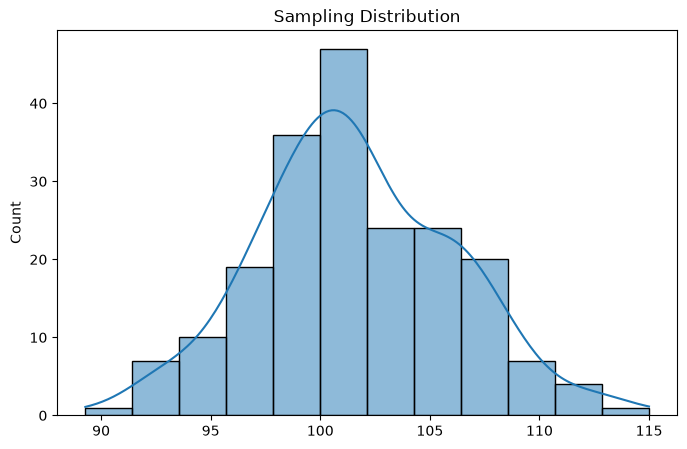

In [7]:
#Cell 8 - Sampling Distribution Plot
plt.figure(figsize=(8,5))

sns.histplot(sample_means,kde=True)

plt.title("Sampling Distribution")

plt.show()

Population Mean : 101.93
Sampling Mean : 101.61


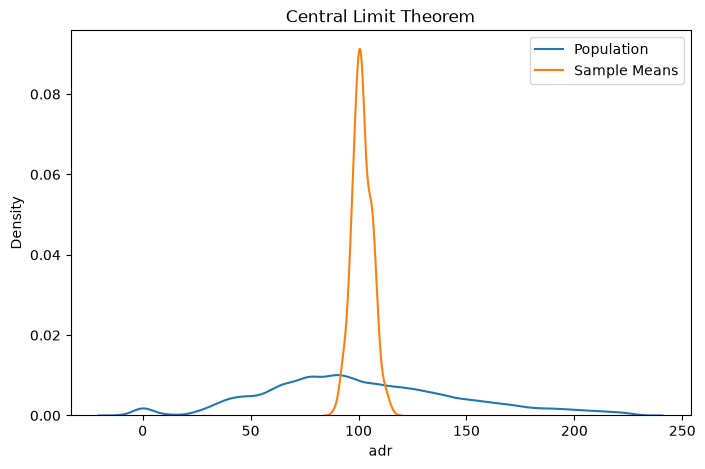

In [8]:
#Central Limit Theorem
print("Population Mean :",round(df["adr"].mean(),2))
print("Sampling Mean :",round(np.mean(sample_means),2))
plt.figure(figsize=(8,5))

sns.kdeplot(df["adr"],label="Population")

sns.kdeplot(sample_means,label="Sample Means")

plt.legend()

plt.title("Central Limit Theorem")

plt.show()

(np.float64(101.62762911931712), np.float64(102.23392733857848))


Text(0.5, 1.0, '95% Confidence Interval')

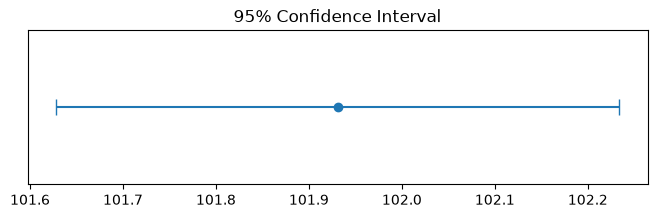

In [9]:
#Confidence Interval

confidence=0.95

mean=df["adr"].mean()

sem=stats.sem(df["adr"])

ci=stats.t.interval(
    confidence,
    len(df)-1,
    loc=mean,
    scale=sem
)

print(ci)

#Confidence Interval Plot
plt.figure(figsize=(8,2))

plt.errorbar(
    mean,
    0,
    xerr=[[mean-ci[0]],[ci[1]-mean]],
    fmt="o",
    capsize=6
)

plt.yticks([])

plt.title("95% Confidence Interval")

In [10]:
#Inferential Statistics
# Population vs Sample
population=len(df)

sample=df.sample(1000,random_state=1)

print("Population Size :",population)

print("Sample Size :",len(sample))

Population Size : 84718
Sample Size : 1000


In [11]:
#Sampling Techniques
random_sample=df.sample(500,random_state=42)

systematic_sample=df.iloc[::20,:]

print("Random Sample :",random_sample.shape)

print("Systematic Sample :",systematic_sample.shape)

Random Sample : (500, 39)
Systematic Sample : (4236, 39)


In [12]:
#Point Estimation
point_estimate=sample["adr"].mean()

print("Point Estimate :",round(point_estimate,2))
#Confidence Level
confidence_level=95

print("Confidence Level :",confidence_level,"%")

Point Estimate : 102.96
Confidence Level : 95 %


In [13]:
#Margin of Error
margin_error=1.96*(
    df["adr"].std()/np.sqrt(len(df))
)

print("Margin of Error :",round(margin_error,2))

Margin of Error : 0.3


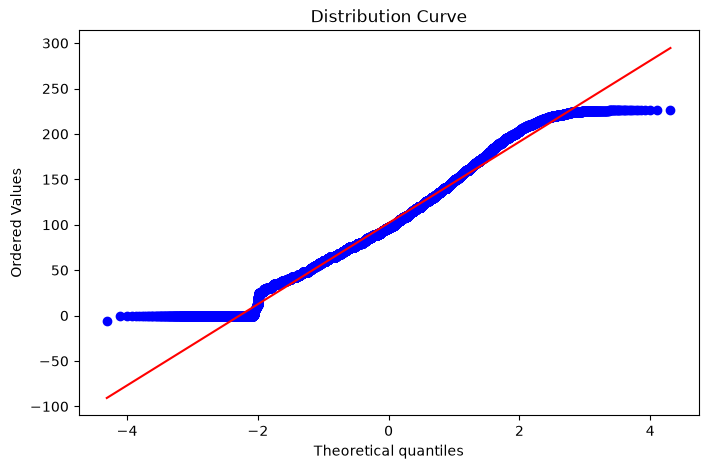

In [14]:
#Distribution Curve
plt.figure(figsize=(8,5))

stats.probplot(df["adr"],dist="norm",plot=plt)

plt.title("Distribution Curve")

plt.show()

In [15]:
#Summary Table
summary=pd.DataFrame({

"Statistic":[
"Population Mean",
"Sample Mean",
"Point Estimate",
"Margin of Error",
"Confidence Level"
],

"Value":[
round(df["adr"].mean(),2),
round(np.mean(sample_means),2),
round(point_estimate,2),
round(margin_error,2),
"95%"
]

})

summary

,Statistic,Value
0,Population Mean,101.93
1,Sample Mean,101.61
2,Point Estimate,102.96
3,Margin of Error,0.3
4,Confidence Level,95%
